In [8]:
import numpy as np, random
from scipy.linalg import norm
from tqdm import tqdm

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [9]:
def refine_grid_2d(HII_DIM, refine_cells, levels):
    """
    Generate a 2D grid with refinement at specified cells.
    
    If a cell is refined, it is replaced by its refined sub-cells.

    Parameters:
        HII_DIM (int): Coarse grid size.
        refine_cells (list): List of (i, j) cells to refine.
        levels (dict): Mapping (i, j) -> refinement level.

    Returns:
        x_grid (np.array): x-coordinates of final cells (lower-left corner).
        y_grid (np.array): y-coordinates of final cells.
        dr (np.array): size of each final cell.
    """
    x_grid = []
    y_grid = []
    dr = []
    
    for i in range(HII_DIM):
        for j in range(HII_DIM):
            if (i, j) in refine_cells:
                level = levels[(i, j)]
                sub_divs = 2**level
                dx = 1.0 / sub_divs
                
                # Refine cell into sub_divs × sub_divs sub-cells
                x_sub_cells = np.linspace(i, i + 1, 2**(level+1) + 1)[1:-1]
                y_sub_cells = np.linspace(j, j + 1, 2**(level+1) + 1)[1:-1]

                for x in x_sub_cells:
                    for y in y_sub_cells:
                        if(x % dx != 0 and y % dx != 0):
                            x_grid.append(x)
                            y_grid.append(y)
                            dr.append(dx)
            else:
                # Only keep coarse cell if it was NOT refined
                x_grid.append(i+0.5)
                y_grid.append(j+0.5)
                dr.append(1.0)
    
    return np.array(x_grid), np.array(y_grid), np.array(dr)


def plot_irregular_grid_cells(r_c, dr, color='white', ax=None):
    for i_c in range(r_c.shape[0]):
        rect = patches.Rectangle((r_c[i_c,0]-dr[i_c]/2, r_c[i_c,1]-dr[i_c]/2), 
                                  dr[i_c], dr[i_c], 
                                  linewidth=0.8,
                                  edgecolor='black',
                                  facecolor=color,
                                  alpha=1.0)
        ax.add_patch(rect)

def plot_ray(r_s, r_t):
    n_st = (r_t - r_s) / norm(r_t - r_s)
    
    t = np.linspace(0., norm(r_t - r_s), 100)
    r_x, r_y = np.zeros_like(t), np.zeros_like(t)
    
    for i_d, d in enumerate(t):
        r_x[i_d] = r_s[0] + d*n_st[0]
        r_y[i_d] = r_s[1] + d*n_st[1]
        
    return r_x, r_y

In [10]:
class LongChar_Raytracing:
    def __init__(self, r_source, r_target, r_cell, dr):
        self.r_source = r_source
        self.r_target = r_target
        self.r_cell = r_cell
        self.dr = dr
        
        print('source:', self.r_source)
        print('target:', self.r_target)
        
        # vector from source to cells
        self.r_st = self.r_target - self.r_source
        self.n_st = self.r_st/norm(self.r_st)
        
        print('source to target:', self.n_st)
        print('distance:', norm(self.r_st))
        
        self.r_touch, self.dr_touch = self.__interacting_cell()

    def __interacting_cell(self):
        # only rays in the direction of the the target
        mask_x = (self.r_cell[:, 0] <= self.r_target[0]) * (self.r_cell[:, 0] >= self.r_source[0])
        mask_y = (self.r_cell[mask_x, 1] <= self.r_target[1]) * (self.r_cell[mask_x, 1] >= self.r_source[1])

        # cells position
        r_c = self.r_cell[mask_x][mask_y]
        dr_grid = self.dr[mask_x][mask_y]

        # source to cells vector
        r_sc = r_c - self.r_source

        # lenght by dot product
        l = r_sc.dot(self.n_st)

        # closest point on the tangent to the cells 
        r_p = self.r_source + l[:,None]*self.n_st[None,:]

        # point onto tanget to cell vector
        r_cp = r_p - r_c

        # select only the cell that are touched by the ray
        mask = np.array([(np.abs(r_cp[i,0]) <= dr_grid[i]/2) and (np.abs(r_cp[i,1]) <= dr_grid[i]/2) for i in range(dr_grid.size)])
        
        # return coordinates and size of the cells interacting with the ray
        r_touch = r_c[mask]
        dr_touch = dr_grid[mask]
        
        return r_touch, dr_touch
    
    def raytracing(self):
        # previous point of interception (init is source position)
        r_inter = np.zeros_like(self.r_touch)
        dist = np.zeros(self.r_touch.shape[0])
        dist_prev = 0

        for idx in range(self.r_touch.shape[0]):  
            # vector to the source to the plane
            r_isp = np.array([self.dr_touch[idx]/2, 0.])
            r_jsp = np.array([0., self.dr_touch[idx]/2])
            #print(r_isp, r_jsp)

            # point on the plane
            p_i0 = self.r_touch[idx] + r_isp
            p_j0 = self.r_touch[idx] + r_jsp

            # normal vector to the surf
            n_iplan = r_isp/norm(r_isp)
            n_jplan = r_jsp/norm(r_jsp)

            # parametric distance of the plan
            d_i = (p_i0-self.r_source).dot(n_iplan)/(self.n_st.dot(n_iplan))
            d_j = (p_j0-self.r_source).dot(n_jplan)/(self.n_st.dot(n_jplan))

            # id of the cell (use this to get the corresponding density)
            if(d_i < d_j):
                r_inter[idx] = self.r_source + d_i*self.n_st
                dist[idx] = d_i - dist_prev
                dist_prev = d_i
            else:
                r_inter[idx] = self.r_source + d_j*self.n_st
                dist[idx] = d_j - dist_prev
                dist_prev = d_j

        # the last cell it stops to the cells coordinate center
        r_inter[-1] = self.r_touch[-1]

        # the distance to the last cell is half that value
        dist[-1] = dist[-1]/2
        return dist, r_inter

## Define irregular grid

In [27]:
# box mesh and cell size
HII_DIM = 28 
dL = 0.6
boxsize = HII_DIM * dL

In [28]:
# define position of the refinde cells
#refine_cells = [(3, 3), (3, 4), (4, 3), (4, 4), (5, 3), (5, 4), (3, 5), (4, 5), (5, 5)]
refine_cells = []

# define level of the refined cells (resolution: 2^levels, similar to Ramses-RT)
#levels = {(3, 3): 2, (3, 4): 1, (4, 3): 1, (4, 4): 1, (5, 3): 1, (5, 4): 1, (3, 5): 1, (4, 5): 1, (5, 5): 1}
levels = {}

# Create refined 2D grid (no specific convention)
x_grid, y_grid, dr = refine_grid_2d(HII_DIM=HII_DIM, refine_cells=refine_cells, levels=levels)

# Coordinate of each cells (at the center of the cell)
r_grid = np.vstack((x_grid, y_grid)).T

## Define source & target position

In [29]:
#r_target = np.array([5.25, 4.25])
#r_target = np.array([5.25, 4.75])
r_target = np.array([5.5, 4.5])+20
r_source = np.array([1.5, 1.5])

## Call the raytracing algorithm

In [30]:
%%time
rt = LongChar_Raytracing(r_source=r_source, r_target=r_target, r_cell=r_grid, dr=dr)

dist, r_inter = rt.raytracing()

source: [1.5 1.5]
target: [25.5 24.5]
source to target: [0.72198821 0.69190536]
distance: 33.24154027718932
CPU times: user 3.32 ms, sys: 249 µs, total: 3.57 ms
Wall time: 3.32 ms


## Calculate Column Density

In [31]:
# density grid
ndens = np.ones((HII_DIM, HII_DIM)) * 1e-3

# column density
ncols = np.zeros((HII_DIM, HII_DIM))

i_t, j_t = (r_target-0.5).astype(int)

for ii, r_th in enumerate(rt.r_touch):
    i, j = (r_th-0.5).astype(int)

    ncols[i_t, j_t] += ndens[i, j] * dist[ii]

## Plot results

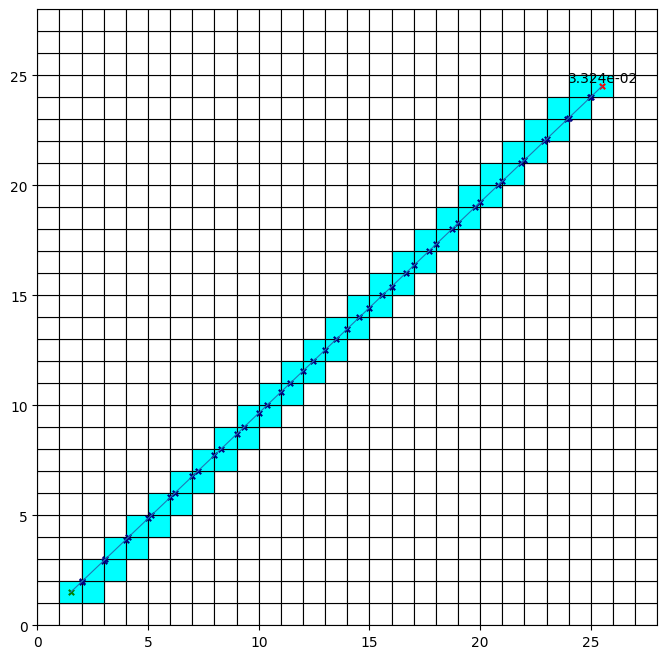

(None, None)

<Figure size 640x480 with 0 Axes>

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_grid, dr=dr, ax=ax)

# plot cells that are touched by the ray
plot_irregular_grid_cells(r_c=rt.r_touch, dr=rt.dr_touch, color='cyan', ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')
ax.scatter(x=r_inter[:-1,0], y=r_inter[:-1,1], s=15, marker='x', color='navy', label='interception')

ax.set_xlim([0, HII_DIM])
ax.set_ylim([0, HII_DIM])

plt.text(x=i_t+0.55, y=j_t+0.55, s='%.3e' %ncols[i_t, j_t], ha='center', va='bottom')

plt.savefig('rt_longchar_grid.png', bbox_inches='tight')
plt.show(), plt.clf()

In [34]:
ncols[i_t, j_t]

0.03324154027718932